There are some global bounds on what variables can realistically be (e.g. even under climate change, mean temperatures shouldn't be 500K anywhere globally!) but we also want to evaluate whether output is within plausible ranges for a given location and time of year. E.g., lots of places are 25C, but 25C in Antarctica in the winter should raise eyebrows. Here we construct plausible ranges for each day of year, based on the variability in the coarse GCM modeled changes relative to the historical, and variability in observations.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from srm import catalog
from srm.qaqc import calculate_reasonable_bounds_doy
from srm.utils import open_icechunk

In [ ]:
import coiled

cluster = coiled.Cluster(n_workers=20, region="us-west-2")  # same region as the S3 bucket
client = cluster.get_client()

## Get data

In [3]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
    # "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/plausible_value_check/"
branch = "v0.11.0"  # "qa-qc-downscaling-step/vtest01"  #

spatial_subset = False

In [4]:
def print_frac_implausible(
    delta_bound_low_min,
    delta_bound_high_max,
    variable=None,
    scenario=None,
    ensemble_member=None,
    log_path=None,
):
    frac_area_too_high = (delta_bound_high_max > 0).mean().values
    frac_area_too_low = (delta_bound_low_min < 0).mean().values
    max_val = delta_bound_high_max.max().values
    min_val = delta_bound_low_min.min().values
    print("Fraction of area too high: " + str(frac_area_too_high))
    print("Fraction of area too low: " + str(frac_area_too_low))

    if log_path is not None:
        df = pd.DataFrame(
            [
                {
                    "variable": variable,
                    "scenario": scenario,
                    "ensemble_member": ensemble_member,
                    "metric": "frac_area_too_high",
                    "value": frac_area_too_high,
                },
                {
                    "variable": variable,
                    "scenario": scenario,
                    "ensemble_member": ensemble_member,
                    "metric": "frac_area_too_low",
                    "value": frac_area_too_low,
                },
                {
                    "variable": variable,
                    "scenario": scenario,
                    "ensemble_member": ensemble_member,
                    "metric": "max_value",
                    "value": max_val,
                },
                {
                    "variable": variable,
                    "scenario": scenario,
                    "ensemble_member": ensemble_member,
                    "metric": "min_value",
                    "value": min_val,
                },
            ]
        )
        df.to_csv(log_path, mode="w", index=False)

# Loop through a bunch of scenarios

In [20]:
var_list = ["tas", "tasmax", "tasmin", "tas", "tasmax", "tasmin", "tas", "tasmax", "tasmin"]
scenario_list = [
    "historical",
    "historical",
    "historical",
    "g6_1p5k",
    "g6_1p5k",
    "g6_1p5k",
    "ssp245",
    "ssp245",
    "ssp245",
]
ens_list = ["r3i1p1f1", "001", "001", "003", "003", "003", "008", "008", "008"]
hist_ensembles = [
    "r3i1p1f1",
    "001",
    "001",
    "r3i1p1f1",
    "001",
    "001",
    "r3i1p1f1",
    "001",
    "001",
]

######################################################
tasmin
ssp245
008
######################################################
Fraction of area too high: 0.007034019109261828
Fraction of area too low: 0.039495685005393744
[58.25 58.5  58.75 59.   64.25 67.25 70.25 70.75 71.   71.25 71.5  71.75
 72.   72.25 75.75 76.  ]
[]


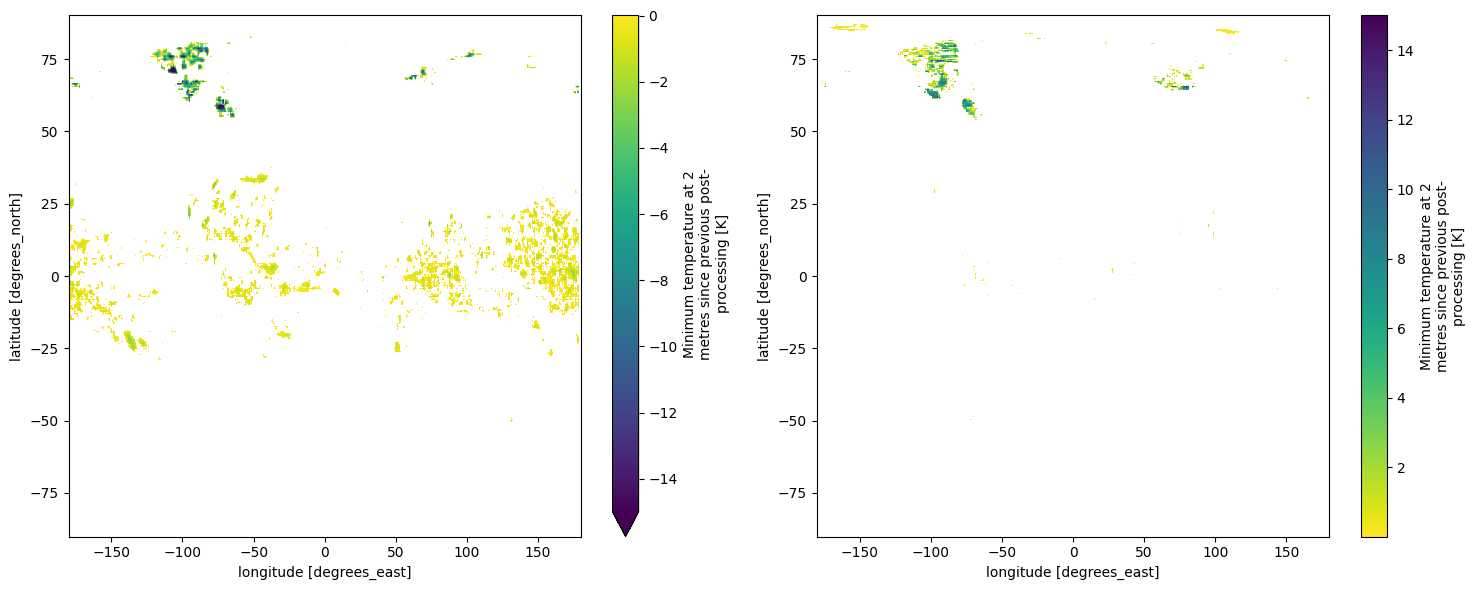

In [6]:
for i, var in enumerate(var_list):
    scenario = scenario_list[i]
    ens = ens_list[i]
    hist_ens = hist_ensembles[i]

    print("######################################################")
    print(var)
    print(scenario)
    print(ens)
    print("######################################################")

    debiased_downscaled = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]

    obs_fine = catalog.get("ERA5").to_xarray()[var]
    obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

    raw_scenario = catalog.get("CESM2-WACCM").to_xarray()[scenario][var].sel(ensemble_member=ens)
    raw_historical = (
        catalog.get("CESM2-WACCM").to_xarray()["historical"][var].sel(ensemble_member=hist_ens)
    )

    # raw_scenario=rechunk(raw_scenario, pattern="full_time").compute()
    # raw_historical=rechunk(raw_historical, pattern="full_time").compute()

    if spatial_subset:
        obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))
        raw_scenario_subset = raw_scenario.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
        raw_historical_subset = raw_historical.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
    else:
        obs_fine_subset = obs_fine
        raw_scenario_subset = raw_scenario
        raw_historical_subset = raw_historical

    low_bound, high_bound = calculate_reasonable_bounds_doy(
        raw_scenario_subset=raw_scenario_subset,
        raw_historical_subset=raw_historical_subset,
        obs_fine_subset=obs_fine_subset,
    )

    debiased_downscaled_max = (
        debiased_downscaled.groupby("time.dayofyear").max(dim="time").compute()
    )
    debiased_downscaled_min = (
        debiased_downscaled.groupby("time.dayofyear").min(dim="time").compute()
    )

    delta_bound_low = debiased_downscaled_min - low_bound
    delta_bound_high = debiased_downscaled_max - high_bound
    delta_bound_low_min = delta_bound_low.min(dim="dayofyear")
    delta_bound_high_max = delta_bound_high.max(dim="dayofyear")

    print_frac_implausible(
        delta_bound_low_min=delta_bound_low_min,
        delta_bound_high_max=delta_bound_high_max,
        variable=var,
        scenario=scenario,
        ensemble_member=ens,
        log_path=path_qaqc + "area_out_of_range_frac_" + var + "_" + scenario + "_" + ens + ".csv",
    )

    print(delta_bound_low_min.where(delta_bound_low_min < -15, drop=True).lat.values)
    print(delta_bound_high_max.where(delta_bound_high_max > 15, drop=True).lat.values)

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    delta_bound_low_min.where(delta_bound_low_min < 0).plot(vmin=-15, vmax=0)

    plt.subplot(1, 2, 2)
    delta_bound_high_max.where(delta_bound_high_max > 0).plot(cmap=plt.cm.viridis_r, vmax=15)
    plt.tight_layout()
    plt.savefig(path_qaqc + "map_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")

# Zoom in on single point

In [33]:
debiased_coarse = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]

In [34]:
# subset to correct bounds
debiased_downscaled = debiased_downscaled.sel(time=slice("2015-01-01", "2069-12-31"))
debiased_coarse = debiased_coarse.sel(time=slice("2015-01-01", "2069-12-31"))

In [37]:
ilat = 71.0
ilon = -109.0

pt_vals = debiased_downscaled.sel(lat=ilat, lon=ilon, method="nearest")
pt_bound_high = high_bound.sel(lat=ilat, lon=ilon, method="nearest")
pt_bound_low = low_bound.sel(lat=ilat, lon=ilon, method="nearest")
pt_raw_scenario_subset = raw_scenario_subset.sel(lat=ilat, lon=ilon, method="nearest")
# raw_historical=rechunk(raw_historical, pattern="full_time").compute()
pt_raw_historical = raw_historical.sel(
    lat=ilat, lon=ilon, method="nearest"
)  # .sel(ensemble_member='001')
pt_coarse_debiased = debiased_coarse.sel(lat=ilat, lon=ilon, method="nearest")

doy = debiased_downscaled["time.dayofyear"]
pt_too_high = pt_vals > pt_bound_high.sel(dayofyear=doy)
pt_too_low = pt_vals < pt_bound_low.sel(dayofyear=doy)

pt_obs = catalog.get("ERA5").to_xarray()[var].sel(lat=ilat, lon=ilon, method="nearest").compute()

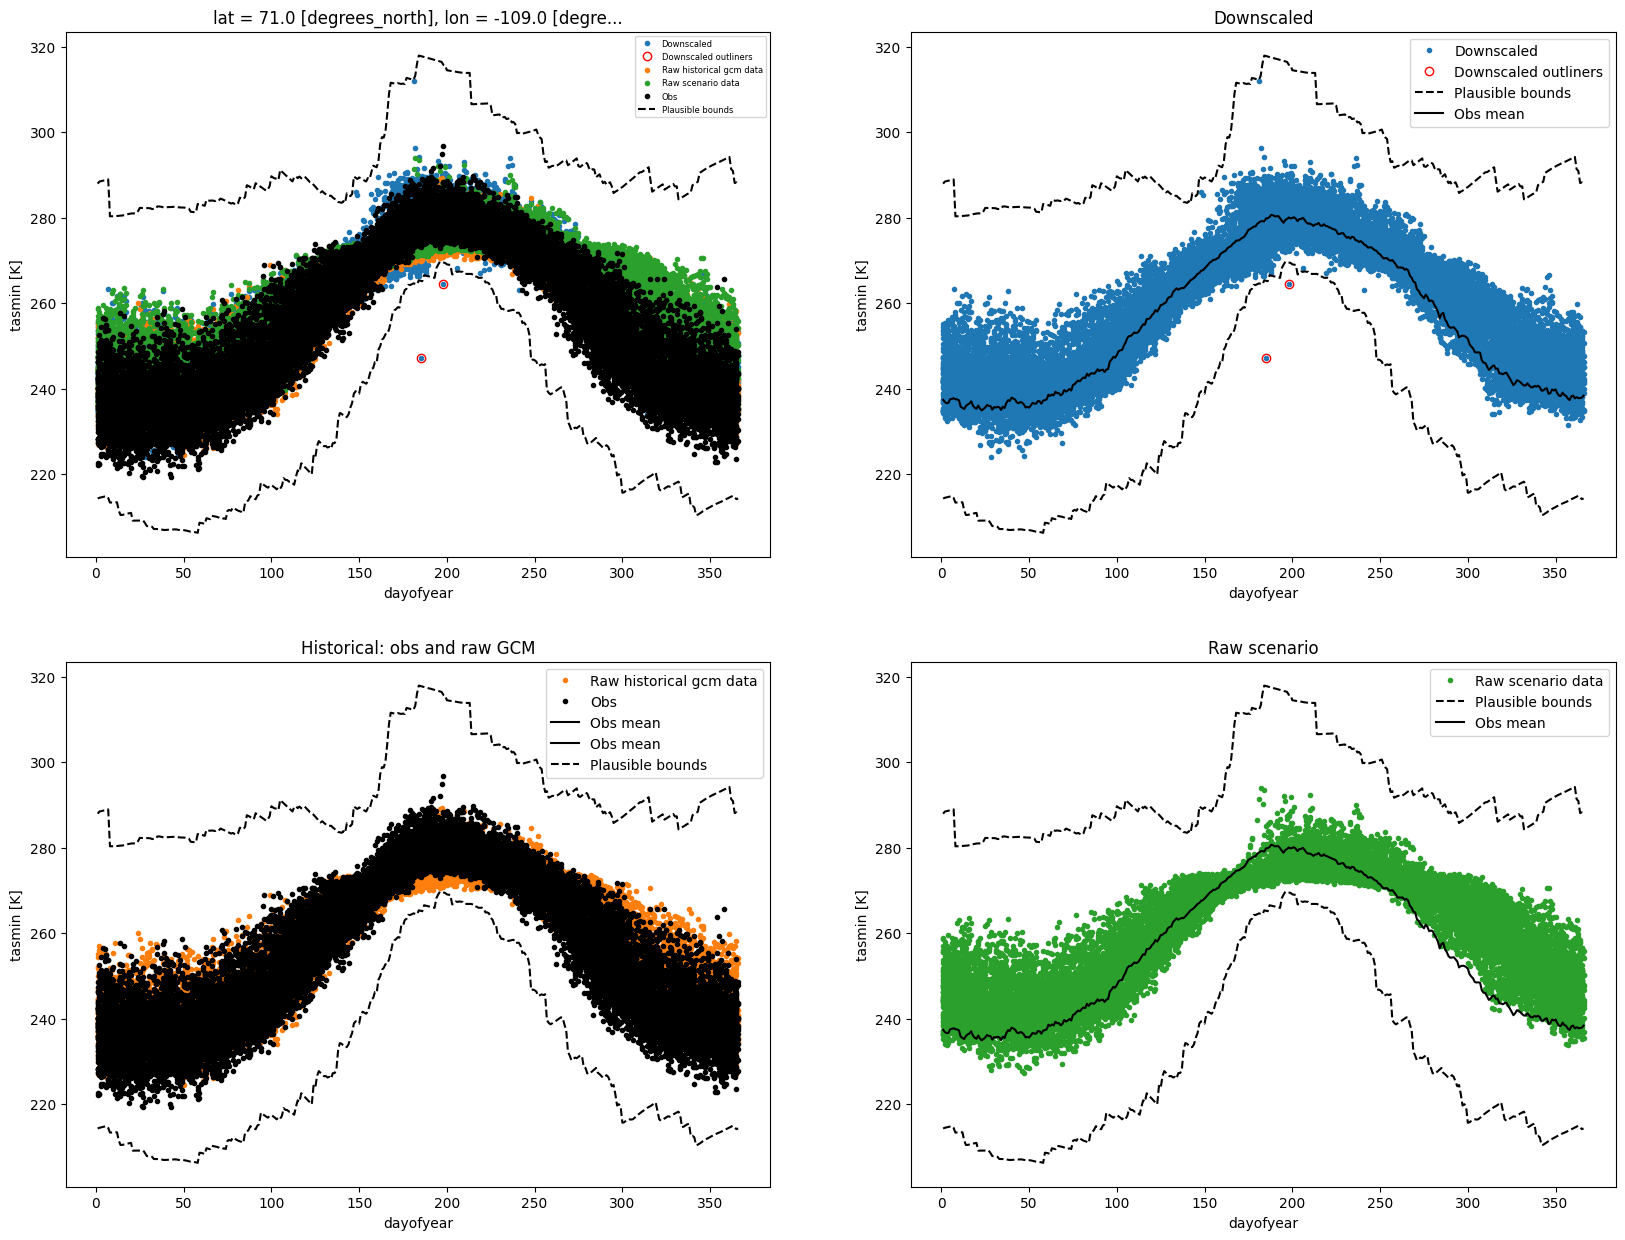

In [40]:
# Look at an example point that is outside the bounds of what is reasonable
plt.figure(figsize=(20, 15))
plt.subplot(2, 2, 1)
plt.plot(pt_vals["time.dayofyear"], pt_vals, ".", label="Downscaled")
plt.plot(
    pt_vals["time.dayofyear"],
    pt_vals.where(pt_too_high),
    "o",
    color="red",
    fillstyle="none",
    label="Downscaled outliners",
)
plt.plot(
    pt_vals["time.dayofyear"], pt_vals.where(pt_too_low), "o", color="red", fillstyle="none"
)  # , label='Downscaled outliners')
plt.plot(
    pt_raw_historical["time.dayofyear"], pt_raw_historical, ".", label="Raw historical gcm data"
)
plt.plot(
    pt_raw_scenario_subset["time.dayofyear"], pt_raw_scenario_subset, ".", label="Raw scenario data"
)
plt.plot(pt_obs["time.dayofyear"], pt_obs, ".k", label="Obs")
pt_bound_high.plot(color="black", linestyle="--", label="Plausible bounds")
pt_bound_low.plot(color="black", linestyle="--")  # ,label='Plausible bounds')
plt.legend(fontsize=6)

plt.subplot(2, 2, 2)
plt.plot(pt_vals["time.dayofyear"], pt_vals, ".", label="Downscaled")
plt.plot(
    pt_vals["time.dayofyear"],
    pt_vals.where(pt_too_high),
    "o",
    color="red",
    fillstyle="none",
    label="Downscaled outliners",
)
plt.plot(
    pt_vals["time.dayofyear"], pt_vals.where(pt_too_low), "o", color="red", fillstyle="none"
)  # , label='Downscaled outliners')
pt_bound_high.plot(color="black", linestyle="--", label="Plausible bounds")
plt.plot(
    pt_obs.groupby("time.dayofyear").mean()["dayofyear"],
    pt_obs.groupby("time.dayofyear").mean(),
    "-k",
    label="Obs mean",
)
pt_bound_low.plot(color="black", linestyle="--")  # ,label='Plausible bounds')
plt.title("Downscaled")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(
    pt_raw_historical["time.dayofyear"],
    pt_raw_historical,
    ".",
    color="C1",
    label="Raw historical gcm data",
)
plt.plot(pt_obs["time.dayofyear"], pt_obs, ".k", label="Obs")
plt.plot(
    pt_obs.groupby("time.dayofyear").mean()["dayofyear"],
    pt_obs.groupby("time.dayofyear").mean(),
    "-k",
    label="Obs mean",
)
plt.plot(
    pt_obs.groupby("time.dayofyear").mean()["dayofyear"],
    pt_obs.groupby("time.dayofyear").mean(),
    "-k",
    label="Obs mean",
)
pt_bound_high.plot(color="black", linestyle="--", label="Plausible bounds")
pt_bound_low.plot(color="black", linestyle="--")  # ,label='Plausible bounds')
plt.title("Historical: obs and raw GCM")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(
    pt_raw_scenario_subset["time.dayofyear"],
    pt_raw_scenario_subset,
    ".",
    color="C2",
    label="Raw scenario data",
)
pt_bound_high.plot(color="black", linestyle="--", label="Plausible bounds")
plt.plot(
    pt_obs.groupby("time.dayofyear").mean()["dayofyear"],
    pt_obs.groupby("time.dayofyear").mean(),
    "-k",
    label="Obs mean",
)
pt_bound_low.plot(color="black", linestyle="--")  # ,label='Plausible bounds')
plt.title("Raw scenario")
plt.legend()

# Combined stats

In [209]:
import glob

dfs = [pd.read_csv(p) for p in glob.glob(path_qaqc + "area_out_of_range_frac_*.csv")]
combined = pd.concat(dfs, ignore_index=True)
combined.to_csv(path_qaqc + "all_sims_local_range_checks.csv", index=False)

In [210]:
combined["flag_less_than_0pt02"] = combined["value"] < 0.02

In [211]:
combined[combined["metric"] == "frac_area_too_high"]

,variable,scenario,ensemble_member,metric,value,flag_less_than_0pt02
0,tasmax,g6_1p5k,3,frac_area_too_high,0.004079,True
4,tas,g6_1p5k,3,frac_area_too_high,0.004264,True
8,tas,ssp245,8,frac_area_too_high,0.011160,True
12,tasmin,historical,1,frac_area_too_high,0.008799,True
16,tasmin,g6_1p5k,3,frac_area_too_high,0.007535,True
20,tasmax,ssp245,8,frac_area_too_high,0.033322,False
24,tasmax,historical,1,frac_area_too_high,0.003299,True
28,tasmin,ssp245,8,frac_area_too_high,0.007034,True
32,tas,historical,r3i1p1f1,frac_area_too_high,0.003024,True


In [212]:
combined[combined["metric"] == "frac_area_too_low"]

,variable,scenario,ensemble_member,metric,value,flag_less_than_0pt02
1,tasmax,g6_1p5k,3,frac_area_too_low,0.002905,True
5,tas,g6_1p5k,3,frac_area_too_low,0.007320,True
9,tas,ssp245,8,frac_area_too_low,0.001589,True
13,tasmin,historical,1,frac_area_too_low,0.001998,True
17,tasmin,g6_1p5k,3,frac_area_too_low,0.064791,False
21,tasmax,ssp245,8,frac_area_too_low,0.002967,True
25,tasmax,historical,1,frac_area_too_low,0.000025,True
29,tasmin,ssp245,8,frac_area_too_low,0.039496,False
33,tas,historical,r3i1p1f1,frac_area_too_low,0.000021,True


In [213]:
combined[combined["metric"] == "max_value"]

,variable,scenario,ensemble_member,metric,value,flag_less_than_0pt02
2,tasmax,g6_1p5k,3,max_value,13.448486,False
6,tas,g6_1p5k,3,max_value,7.091339,False
10,tas,ssp245,8,max_value,9.839233,False
14,tasmin,historical,1,max_value,6.105469,False
18,tasmin,g6_1p5k,3,max_value,14.474091,False
22,tasmax,ssp245,8,max_value,13.072021,False
26,tasmax,historical,1,max_value,3.341248,False
30,tasmin,ssp245,8,max_value,13.202362,False
34,tas,historical,r3i1p1f1,max_value,3.585205,False


In [214]:
combined[combined["metric"] == "min_value"]

,variable,scenario,ensemble_member,metric,value,flag_less_than_0pt02
3,tasmax,g6_1p5k,3,min_value,-13.380493,True
7,tas,g6_1p5k,3,min_value,-9.620911,True
11,tas,ssp245,8,min_value,-8.768921,True
15,tasmin,historical,1,min_value,-5.094086,True
19,tasmin,g6_1p5k,3,min_value,-20.584960,True
23,tasmax,ssp245,8,min_value,-15.289124,True
27,tasmax,historical,1,min_value,-0.891663,True
31,tasmin,ssp245,8,min_value,-25.267105,True
35,tas,historical,r3i1p1f1,min_value,-0.354126,True
